# Эксперимент 02: TF-IDF поиск

**Цель:** Построить базовую систему поиска на основе TF-IDF + cosine similarity.

**Используемые данные:** 29 чанков из `data/` (ml_docs + python_docs)

**Основные выводы:** TF-IDF хорошо работает при точном совпадении слов запроса с текстом, но плохо понимает синонимы и перефразировки.

---

## 1. Загрузка данных и обучение модели

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.data.loader import load_and_chunk_documents
from src.models.tfidf_search import TFIDFSearch

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

# Загружаем данные
chunks = load_and_chunk_documents('../data')
print(f'Загружено чанков: {len(chunks)}')

# Обучаем TF-IDF модель
model = TFIDFSearch()
model.fit(chunks)

Загружено чанков: 29
TF-IDF модель обучена.
  Чанков в индексе: 29
  Размер словаря: 3820 слов


## 2. Тестирование поиска

In [2]:
def show_results(query: str, top_k: int = 3):
    """Красиво выводит результаты поиска."""
    results = model.search(query, top_k=top_k)
    print(f'Запрос: "{query}"')
    print('-' * 60)
    if not results:
        print('Ничего не найдено.')
        return
    for r in results:
        print(f"#{r['rank']} score={r['score']:.4f} | [{r['category']}] {r['filename']}")
        print(f"   {r['text'][:200]}...")
        print()

# Запрос 1: точное совпадение слов
show_results('переобучение методы борьбы')

Запрос: "переобучение методы борьбы"
------------------------------------------------------------
#1 score=0.1173 | [ml_docs] overfitting.txt
   Переобучение (Overfitting) Переобучение — это ситуация, когда модель машинного обучения слишком хорошо подстраивается под обучающие данные, но плохо работает на новых, ранее не виденных данных. Причин...

#2 score=0.1119 | [ml_docs] underfitting.txt
   Недообучение (Underfitting) Недообучение — это ситуация, когда модель слишком проста и не может уловить закономерности даже в обучающих данных. Модель плохо работает как на обучающих, так и на тестовы...

#3 score=0.0809 | [ml_docs] underfitting.txt
   модель систематически ошибается. - Переобучение = высокая дисперсия (variance) — модель слишком чувствительна к данным. - Цель — найти баланс между ними. Проверка через кривые обучения (learning curve...



In [3]:
# Запрос 2: Python документация
show_results('как использовать словарь dict в python')

Запрос: "как использовать словарь dict в python"
------------------------------------------------------------
#1 score=0.1011 | [python_docs] introduction.txt
   Введение в Python Python — это высокоуровневый язык программирования с динамической типизацией и простым синтаксисом. Он широко используется в науке о данных, веб-разработке, автоматизации и искусстве...

#2 score=0.0597 | [python_docs] data_structures.txt
   value in person.items(): print(f"{key}: {value}") person.keys() # все ключи person.values() # все значения Множество (Set): Коллекция уникальных элементов. Не упорядочена. my_set = {1, 2, 3, 2, 1} # →...

#3 score=0.0568 | [python_docs] introduction.txt
   x = 10 name = "Python" is_cool = True Арифметические операции: a = 10 + 5 # сложение → 15 b = 10 - 3 # вычитание → 7 c = 4 * 3 # умножение → 12 d = 10 / 3 # деление → 3.333... e = 10 // 3 # целочислен...



In [4]:
# Запрос 3: ML метрики
show_results('метрики качества классификации accuracy f1')

Запрос: "метрики качества классификации accuracy f1"
------------------------------------------------------------
#1 score=0.1628 | [ml_docs] classification.txt
   Классификация (Classification) Классификация — задача машинного обучения, в которой нужно предсказать категорию (класс) объекта. Например: спам/не спам, кошка/собака, болен/здоров. Типы классификации:...

#2 score=0.0658 | [ml_docs] regression.txt
   Регрессия (Regression) Регрессия — задача машинного обучения, в которой нужно предсказать непрерывное числовое значение. Например: цена квартиры, температура завтра, объём продаж. Отличие от классифик...

#3 score=0.0321 | [ml_docs] classification.txt
   (полнота) — из всех реальных положительных, сколько мы нашли. - F1-score — гармоническое среднее Precision и Recall. Баланс между ними. - ROC-AUC — площадь под кривой ROC. Чем ближе к 1, тем лучше. - ...



In [5]:
# Запрос 4: синоним — здесь TF-IDF может ошибиться
# Слово "недостаточное обучение" — синоним к "underfitting", которого нет в тексте явно
show_results('модель плохо обучается на тренировочных данных')

Запрос: "модель плохо обучается на тренировочных данных"
------------------------------------------------------------
#1 score=0.1236 | [ml_docs] underfitting.txt
   Недообучение (Underfitting) Недообучение — это ситуация, когда модель слишком проста и не может уловить закономерности даже в обучающих данных. Модель плохо работает как на обучающих, так и на тестовы...

#2 score=0.0857 | [ml_docs] train_test_split.txt
   Разбиение данных на обучающую и тестовую выборки (Train-Test Split) Разбиение данных — обязательный шаг при разработке модели машинного обучения. Данные делятся на части: для обучения модели и для про...

#3 score=0.0849 | [ml_docs] overfitting.txt
   Переобучение (Overfitting) Переобучение — это ситуация, когда модель машинного обучения слишком хорошо подстраивается под обучающие данные, но плохо работает на новых, ранее не виденных данных. Причин...



In [6]:
# Запрос 5: нейронные сети
show_results('как работает backpropagation и обратное распространение')

Запрос: "как работает backpropagation и обратное распространение"
------------------------------------------------------------
#1 score=0.1472 | [ml_docs] neural_networks.txt
   Нейронные сети (Neural Networks) Нейронная сеть — это вычислительная модель, вдохновлённая работой мозга. Состоит из слоёв нейронов (узлов), которые передают сигналы друг другу с определёнными весами....

#2 score=0.0412 | [ml_docs] embeddings.txt
   Эмбеддинги (Embeddings) Эмбеддинги — это числовые представления объектов (слов, предложений, документов) в виде векторов в многомерном пространстве. Близкие по смыслу объекты имеют близкие векторы. За...

#3 score=0.0178 | [ml_docs] underfitting.txt
   Недообучение (Underfitting) Недообучение — это ситуация, когда модель слишком проста и не может уловить закономерности даже в обучающих данных. Модель плохо работает как на обучающих, так и на тестовы...



## 3. Визуализация матрицы схожести

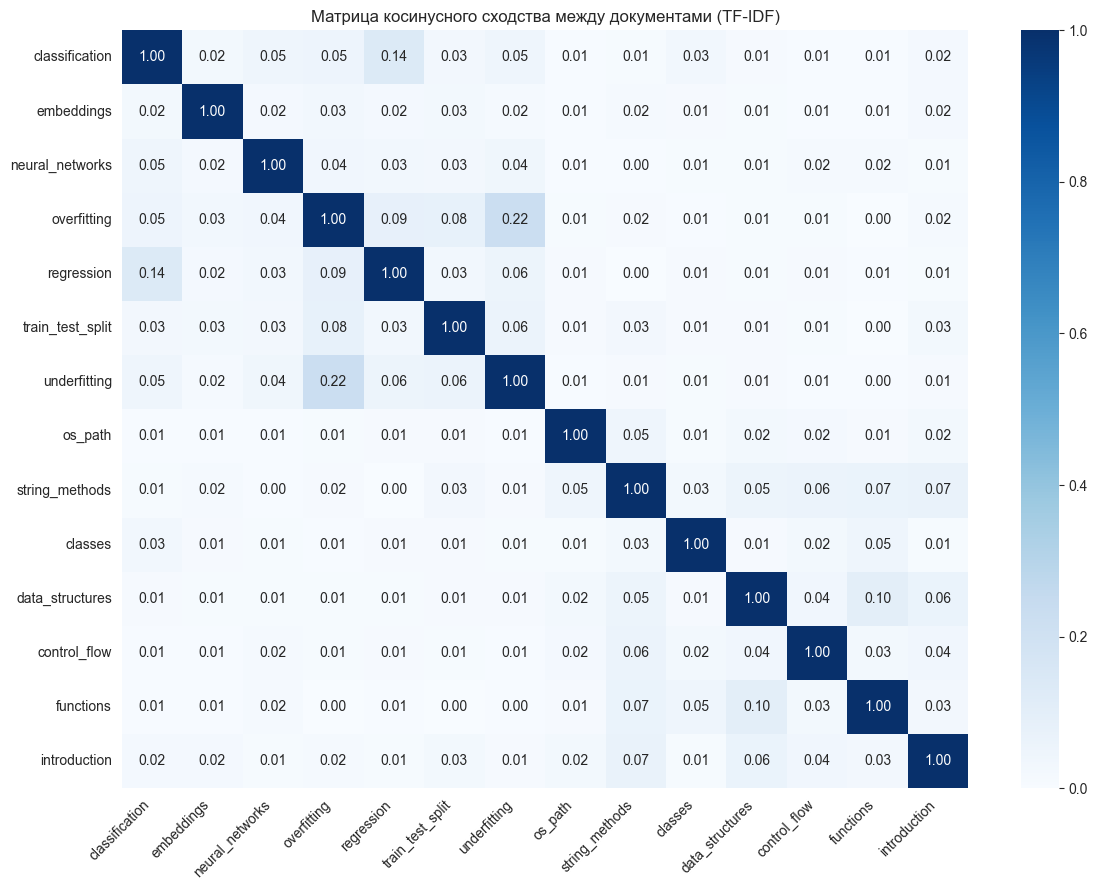

График сохранён в artifacts/tfidf_similarity_matrix.png


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Берём первый чанк из каждого документа для наглядности
seen = set()
sample_chunks = []
for chunk in chunks:
    if chunk['filename'] not in seen and chunk['chunk_id'] == 0:
        seen.add(chunk['filename'])
        sample_chunks.append(chunk)

# Вычисляем матрицу схожести между первыми чанками
texts = [c['text'] for c in sample_chunks]
labels = [c['filename'].replace('.txt', '') for c in sample_chunks]

vecs = model.vectorizer.transform(texts)
sim_matrix = cosine_similarity(vecs)

# Рисуем тепловую карту
plt.figure(figsize=(12, 9))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0, vmax=1
)
plt.title('Матрица косинусного сходства между документами (TF-IDF)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../artifacts/tfidf_similarity_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён в artifacts/tfidf_similarity_matrix.png')

## 4. Оценка качества поиска

In [8]:
# Тестовые пары: запрос → ожидаемый файл-источник
# Проверяем: попадает ли правильный файл в топ-3 результатов?

test_cases = [
    ('переобучение регуляризация dropout',        'overfitting.txt'),
    ('недообучение bias variance tradeoff',       'underfitting.txt'),
    ('классификация accuracy precision recall',   'classification.txt'),
    ('регрессия MAE MSE R2',                      'regression.txt'),
    ('train test split кросс-валидация',          'train_test_split.txt'),
    ('нейронная сеть backpropagation adam',       'neural_networks.txt'),
    ('эмбеддинги sentence transformers cosine',  'embeddings.txt'),
    ('функции python lambda аргументы',           'functions.txt'),
    ('список словарь tuple set python',           'data_structures.txt'),
    ('классы наследование init python',           'classes.txt'),
]

hits = 0
rows = []
for query, expected_file in test_cases:
    results = model.search(query, top_k=3)
    found_files = [r['filename'] for r in results]
    hit = expected_file in found_files
    if hit:
        hits += 1
    rows.append({
        'query': query[:40] + '...' if len(query) > 40 else query,
        'expected': expected_file,
        'top1': found_files[0] if found_files else '-',
        'hit@3': '✓' if hit else '✗',
    })

df_eval = pd.DataFrame(rows)
print(df_eval.to_string(index=False))
print(f'\nHit@3 accuracy: {hits}/{len(test_cases)} = {hits/len(test_cases):.0%}')

                                  query             expected                 top1 hit@3
     переобучение регуляризация dropout      overfitting.txt      overfitting.txt     ✓
    недообучение bias variance tradeoff     underfitting.txt     underfitting.txt     ✓
классификация accuracy precision recall   classification.txt   classification.txt     ✓
                   регрессия MAE MSE R2       regression.txt       regression.txt     ✓
       train test split кросс-валидация train_test_split.txt train_test_split.txt     ✓
    нейронная сеть backpropagation adam  neural_networks.txt  neural_networks.txt     ✓
эмбеддинги sentence transformers cosine       embeddings.txt       embeddings.txt     ✓
        функции python lambda аргументы        functions.txt        functions.txt     ✓
        список словарь tuple set python  data_structures.txt     introduction.txt     ✓
        классы наследование init python          classes.txt          classes.txt     ✓

Hit@3 accuracy: 10/10 = 100%


## 5. Сохранение модели

In [9]:
# Сохраняем обученную модель чтобы не переобучать каждый раз
model.save('../artifacts/tfidf_model.pkl')
print('Готово!')

Модель сохранена: ../artifacts/tfidf_model.pkl
Готово!


## 6. Выводы

**TF-IDF поиск:**
- Хорошо работает когда слова запроса совпадают со словами в тексте
- Быстрый: обучение за секунды, поиск мгновенный
- Не понимает смысл: синонимы и перефразировки дают плохой результат
- Метрика Hit@3 показывает долю запросов, где правильный документ попал в топ-3

**Следующий шаг:** улучшим качество поиска через sentence-transformers — они понимают смысл, а не только слова.